In [1]:
import pickle
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

C:\Users\noton\miniconda3\envs\Deep2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = GCNConv(30, 256)
        self.conv2 = GCNConv(256, 256)
        self.conv3 = GCNConv(256, 256)
        self.conv4 = GCNConv(256, 256)
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = F.relu(x)
        x = global_max_pool(x, data.batch)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        return x

In [3]:
def custom_collate(batch):
    data_list, target_list = zip(*batch)
    batch_data = Batch.from_data_list(data_list)
    batch_target = torch.stack(target_list)
    return batch_data, batch_target

Dataset :  AI+Human
Epoch 1, Validation Loss: 0.27196360259233987
Epoch 2, Validation Loss: 0.15495610391391884
Epoch 3, Validation Loss: 0.1420054652697569
Epoch 4, Validation Loss: 0.11726007506084841
Epoch 5, Validation Loss: 0.12245775346145049
Epoch 6, Validation Loss: 0.09522557559110259
Epoch 7, Validation Loss: 0.07389868365906556
Epoch 8, Validation Loss: 0.06708360418903674
Epoch 9, Validation Loss: 0.059444212761370296
Epoch 10, Validation Loss: 0.055146202846559564
Epoch 11, Validation Loss: 0.07261173432924058
Epoch 12, Validation Loss: 0.06470486749716216
Epoch 13, Validation Loss: 0.045327729415379055
Epoch 14, Validation Loss: 0.04275061337513771
Epoch 15, Validation Loss: 0.041288692118546216
Epoch 16, Validation Loss: 0.03885620526494573
Epoch 17, Validation Loss: 0.03910695660779636
Epoch 18, Validation Loss: 0.03769722157929384
Epoch 19, Validation Loss: 0.041452855913598784
Epoch 20, Validation Loss: 0.04452722790936776
Epoch 21, Validation Loss: 0.0460972333657746

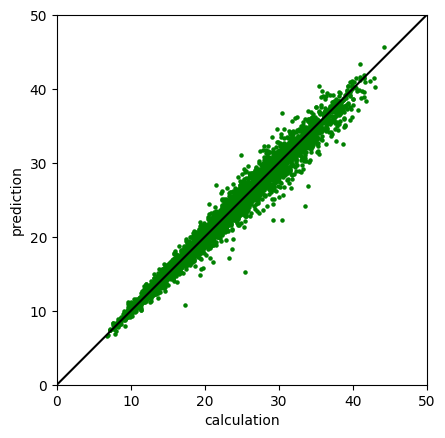

Dataset :  AI2+Human
Epoch 1, Validation Loss: 0.39916524483899835
Epoch 2, Validation Loss: 0.19712526722309084
Epoch 3, Validation Loss: 0.1433419169551407
Epoch 4, Validation Loss: 0.11475710049784071
Epoch 5, Validation Loss: 0.09624719536722305
Epoch 6, Validation Loss: 0.07779019562018086
Epoch 7, Validation Loss: 0.06860097191696332
Epoch 8, Validation Loss: 0.05633801783516091
Epoch 9, Validation Loss: 0.049365244203411686
Epoch 10, Validation Loss: 0.04307791422170597
Epoch 11, Validation Loss: 0.042668461837407815
Epoch 12, Validation Loss: 0.04810732997516142
Epoch 13, Validation Loss: 0.046401774435894945
Epoch 14, Validation Loss: 0.047383537354074044
Epoch 15, Validation Loss: 0.04848315616788106
Epoch 16, Validation Loss: 0.0434700125099365
Epoch 17, Validation Loss: 0.03928159145645981
Epoch 18, Validation Loss: 0.035022908214760694
Epoch 19, Validation Loss: 0.03774858159747332
Epoch 20, Validation Loss: 0.03169732398369559
Epoch 21, Validation Loss: 0.0357865893633309

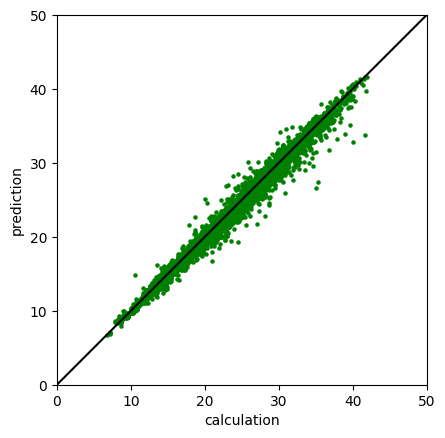

Dataset :  Random+Human
Epoch 1, Validation Loss: 0.2926402804116476
Epoch 2, Validation Loss: 0.1802103482254725
Epoch 3, Validation Loss: 0.1318521401139096
Epoch 4, Validation Loss: 0.10902647936434247
Epoch 5, Validation Loss: 0.09012069301989835
Epoch 6, Validation Loss: 0.08857125894340366
Epoch 7, Validation Loss: 0.08245867503323412
Epoch 8, Validation Loss: 0.07830519621383936
Epoch 9, Validation Loss: 0.06591261325615962
Epoch 10, Validation Loss: 0.07624889322472256
Epoch 11, Validation Loss: 0.06344303660077705
Epoch 12, Validation Loss: 0.05110298324509894
Epoch 13, Validation Loss: 0.04599030058343814
Epoch 14, Validation Loss: 0.04577770995615265
Epoch 15, Validation Loss: 0.0376982434410834
Epoch 16, Validation Loss: 0.03750951899957381
Epoch 17, Validation Loss: 0.03556697922391225
Epoch 18, Validation Loss: 0.0328482412314369
Epoch 19, Validation Loss: 0.040941353161997325
Epoch 20, Validation Loss: 0.035686789042391885
Epoch 21, Validation Loss: 0.03357017253420934
E

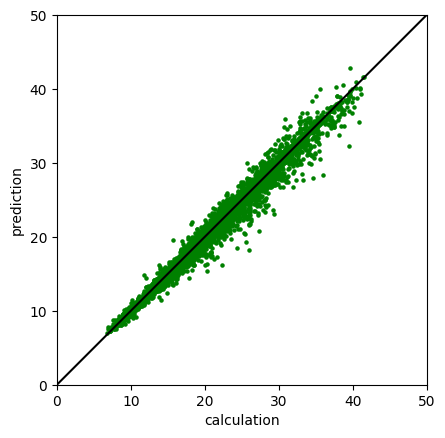

Dataset :  AI+Random
Epoch 1, Validation Loss: 0.1665160783055613
Epoch 2, Validation Loss: 0.10787933152708716
Epoch 3, Validation Loss: 0.0829219483209182
Epoch 4, Validation Loss: 0.07163195638278828
Epoch 5, Validation Loss: 0.06472556190145734
Epoch 6, Validation Loss: 0.05693498140306115
Epoch 7, Validation Loss: 0.05130527335120339
Epoch 8, Validation Loss: 0.04778219992566246
Epoch 9, Validation Loss: 0.04475155999366966
Epoch 10, Validation Loss: 0.04528126257335425
Epoch 11, Validation Loss: 0.04261368786848634
Epoch 12, Validation Loss: 0.040820408181522896
Epoch 13, Validation Loss: 0.03784391216950531
Epoch 14, Validation Loss: 0.036978682138600484
Epoch 15, Validation Loss: 0.03578942010809532
Epoch 16, Validation Loss: 0.036076068841925074
Epoch 17, Validation Loss: 0.03704178538647832
Epoch 18, Validation Loss: 0.044186446339760495
Epoch 19, Validation Loss: 0.039954073537112944
Epoch 20, Validation Loss: 0.03635724708752076
Epoch 21, Validation Loss: 0.0315184601963188

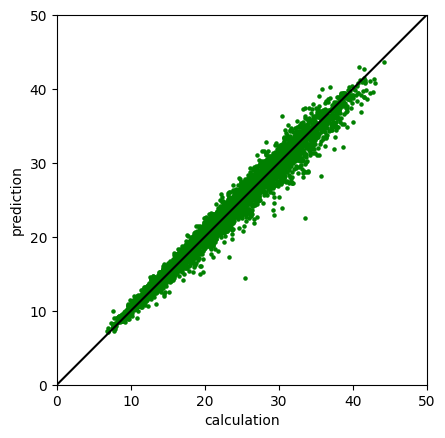

Dataset :  AI2+Random
Epoch 1, Validation Loss: 0.36716078515381856
Epoch 2, Validation Loss: 0.15343892771362067
Epoch 3, Validation Loss: 0.0985630238488641
Epoch 4, Validation Loss: 0.08250439926567875
Epoch 5, Validation Loss: 0.07672232969158309
Epoch 6, Validation Loss: 0.08596464552617376
Epoch 7, Validation Loss: 0.06958451101155552
Epoch 8, Validation Loss: 0.05691137592648583
Epoch 9, Validation Loss: 0.05282010638765403
Epoch 10, Validation Loss: 0.05082212432593663
Epoch 11, Validation Loss: 0.04839004795082336
Epoch 12, Validation Loss: 0.047951435238805705
Epoch 13, Validation Loss: 0.04719544942906129
Epoch 14, Validation Loss: 0.04685684231504949
Epoch 15, Validation Loss: 0.04141028577721428
Epoch 16, Validation Loss: 0.0408530862531502
Epoch 17, Validation Loss: 0.03979942256666322
Epoch 18, Validation Loss: 0.03819138735270634
Epoch 19, Validation Loss: 0.03836319534707868
Epoch 20, Validation Loss: 0.03609271004118236
Epoch 21, Validation Loss: 0.035381318719760586


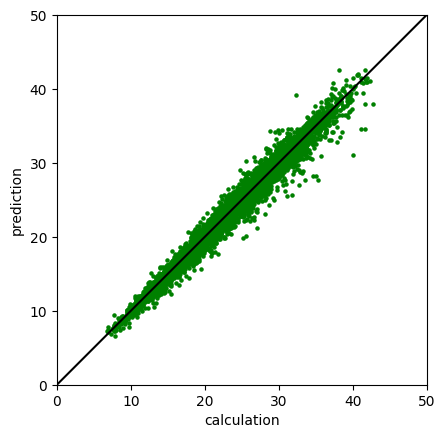

Dataset :  AI+AI2
Epoch 1, Validation Loss: 0.2221412451239008
Epoch 2, Validation Loss: 0.1347546236828927
Epoch 3, Validation Loss: 0.1005853222449868
Epoch 4, Validation Loss: 0.08133702765438693
Epoch 5, Validation Loss: 0.0860120692913162
Epoch 6, Validation Loss: 0.06964321265380369
Epoch 7, Validation Loss: 0.0932103161547359
Epoch 8, Validation Loss: 0.09740649176983822
Epoch 9, Validation Loss: 0.08572514909012005
Epoch 10, Validation Loss: 0.08209694047170786
Epoch 11, Validation Loss: 0.08120753216733446
Epoch 12, Validation Loss: 0.07519285693568706
Epoch 13, Validation Loss: 0.07096864282546503
Epoch 14, Validation Loss: 0.06079995951826121
Epoch 15, Validation Loss: 0.054963261535364794
Epoch 16, Validation Loss: 0.05087764243313082
Epoch 17, Validation Loss: 0.05580552240666235
Epoch 18, Validation Loss: 0.07144560767450497
Epoch 19, Validation Loss: 0.05502292191318696
Epoch 20, Validation Loss: 0.047601175426885106
Epoch 21, Validation Loss: 0.04916951830886791
Epoch 2

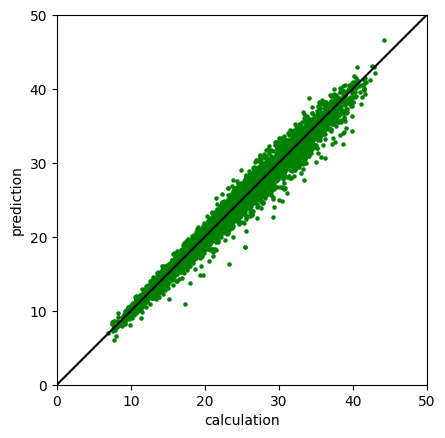

In [4]:
torch.manual_seed(0)

target_data = "abcgg"
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
    
for d in ["AI+Human", "AI2+Human", "Random+Human", "AI+Random", "AI2+Random", "AI+AI2"]:
    torch.manual_seed(0)
    print('Dataset : ', d)
    dataset = d

    with open(f'data_{dataset}/data_train_list.pkl', 'rb') as f:
        data_train_list = pickle.load(f)
    with open(f'data_{dataset}/data_val_list.pkl', 'rb') as f:
        data_val_list = pickle.load(f)
    with open(f'data_{dataset}/data_test_list.pkl', 'rb') as f:
        data_test_list = pickle.load(f)
    with open(f'data_{dataset}/target_train_{target_data}.pkl', 'rb') as f:
        target_train = pickle.load(f)
    with open(f'data_{dataset}/target_val_{target_data}.pkl', 'rb') as f:
        target_val = pickle.load(f)
    with open(f'data_{dataset}/target_test_{target_data}.pkl', 'rb') as f:
        target_test = pickle.load(f)
    
    scaler = StandardScaler()
    target_train = scaler.fit_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_val = scaler.transform(np.array(target_val).reshape(-1, 1)).flatten()
    target_test = scaler.transform(np.array(target_test).reshape(-1, 1)).flatten()
    target_train = torch.tensor(target_train, dtype=torch.float32)
    target_val = torch.tensor(target_val, dtype=torch.float32)
    target_test = torch.tensor(target_test, dtype=torch.float32)

    train_loader = DataLoader(list(zip(data_train_list, target_train)), batch_size=128, collate_fn=custom_collate)
    val_loader = DataLoader(list(zip(data_val_list, target_val)), batch_size=128, collate_fn=custom_collate)
    test_loader = DataLoader(list(zip(data_test_list, target_test)), batch_size=128, collate_fn=custom_collate)

    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    early_stopping_patience = 30
    best_val_loss = float('inf')
    patience_counter = 0

    loss_train = []
    for epoch in range(100):
        model.train()
        for data, target in train_loader:
            data = data.to(device)
            target = target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target.view(-1, 1))
            loss.backward()
            optimizer.step()
            loss_train.append(loss.item())
        
        model.eval()
        val_loss = 0
        total_size = 0
        with torch.no_grad():
            for data, target in val_loader:
                data = data.to(device)
                target = target.to(device)
                out = model(data)
                loss = criterion(out, target.view(-1, 1))
                val_loss += loss.item() * data.size(0)
                total_size += data.size(0)
        val_loss /= total_size
        
        print(f'Epoch {epoch+1}, Validation Loss: {val_loss}')
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f'data_{dataset}/model_{dataset}_sc.pth')
        else:
            patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    model.load_state_dict(torch.load(f'data_{dataset}/model_{dataset}_sc.pth'))
    model.eval()
    
    pred_train = []
    for data, target in train_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_train.append(out.cpu().numpy())
    pred_train = np.concatenate(pred_train)

    pred_test = []
    for data, target in test_loader:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
        pred_test.append(out.cpu().numpy())
    pred_test = np.concatenate(pred_test)

    pred_train = scaler.inverse_transform(pred_train)
    pred_test = scaler.inverse_transform(pred_test)
    target_train = scaler.inverse_transform(np.array(target_train).reshape(-1, 1)).flatten()
    target_test = scaler.inverse_transform(np.array(target_test).reshape(-1, 1)).flatten()

    print('R2 train:', metrics.r2_score(target_train, pred_train))
    print('R2 test:', metrics.r2_score(target_test, pred_test))
    
    n = 50
    fig = plt.figure()
    ax = fig.add_subplot(111)
    plt.plot(range(0, n+1), range(0, n+1), c='black')
    plt.scatter(target_test, pred_test, c='green', s=5)
    plt.xlim(0, n)
    plt.ylim(0, n)
    ax.set_aspect('equal', adjustable='box')
    plt.xlabel("calculation")
    plt.ylabel("prediction")
    plt.show()
    fig.savefig(f'data_{dataset}/source_sc.pdf')
    print('======================================================')